   age  sex  cp trestbps chol fbs restecg thalach exang  oldpeak slope ca  \
0   28    1   2      130  132   0       2     185     0      0.0     ?  ?   
1   29    1   2      120  243   0       0     160     0      0.0     ?  ?   
2   29    1   2      140    ?   0       0     170     0      0.0     ?  ?   
3   30    0   1      170  237   0       1     170     0      0.0     ?  ?   
4   31    0   2      100  219   0       1     150     0      0.0     ?  ?   

  thal  num         
0    ?           0  
1    ?           0  
2    ?           0  
3    6           0  
4    ?           0  
     chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  num
0     132    0        2      185      0        0      0   0     0    0
1     243    0        0      160      0        0      0   0     0    0
2       0    0        0      170      0        0      0   0     0    0
3     237    0        1      170      0        0      0   0     6    0
4     219    0        1      150      0        0      0 

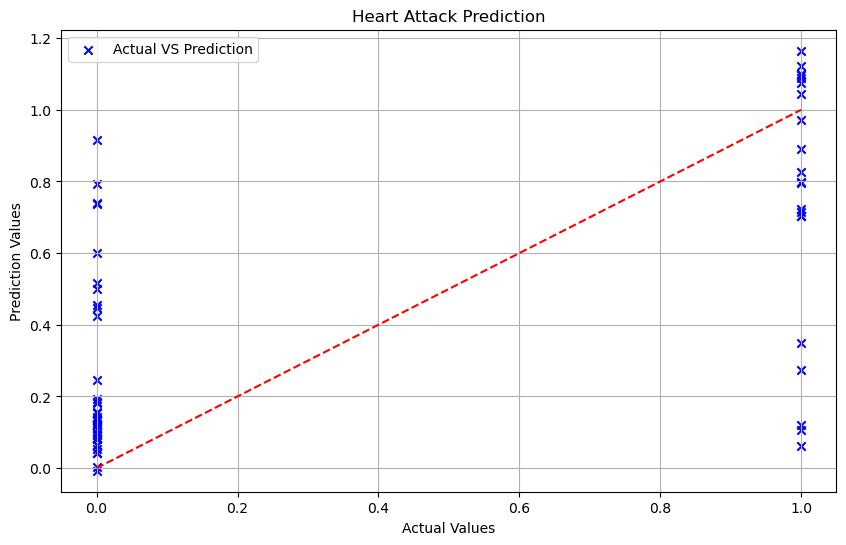

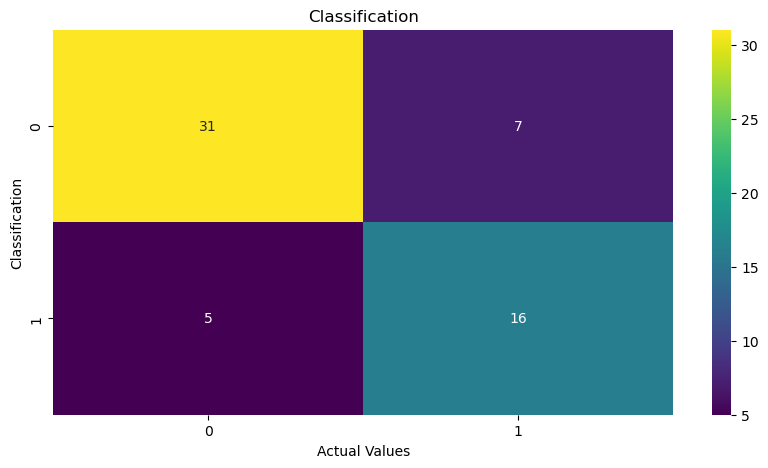

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, confusion_matrix, accuracy_score

data = pd.read_csv("C:/Users/SRYam/Downloads/data.csv")
data.head()
df = pd.DataFrame(data)
print(df.head())
#Handling Objects: Column names are often stored as "Objects" in Pandas. The .str accessor "unlocks" string-specific tools (like strip, lower, replace, or contains) for those objects.
df.columns = df.columns.str.strip()
df = df[['chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','num']].apply(pd.to_numeric,errors='coerce')
df = df.fillna(0)
df['chol'] = df['chol'].astype(int)
df['fbs'] = df['fbs'].astype(int)
df['restecg'] = df['restecg'].astype(int)
df['thalach'] = df['thalach'].astype(int)
df['exang'] = df['exang'].astype(int)
df['oldpeak'] = df['oldpeak'].astype(int)
df['slope'] = df['slope'].astype(int)
df['ca'] = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)
df['num'] = df['num'].astype(int)

#imputation

df['chol'] = df['chol'].fillna(df['chol'].mean())
df['fbs'] = df['fbs'].fillna(df['fbs'].mean())
df['restecg'] = df['restecg'].fillna(df['restecg'].mean())
df['thalach'] = df['thalach'].fillna(df['thalach'].mean())
df['exang'] = df['exang'].fillna(df['exang'].mean())
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].mean())
df['slope'] = df['slope'].fillna(df['slope'].mean())
df['ca'] = df['ca'].fillna(df['ca'].mean())
df['thal'] = df['thal'].fillna(df['thal'].mean())
df['num'] = df['num'].fillna(df['num'].mean())

print(df)
df.to_csv("New_data",index=False)

df = df.dropna()
x = df.drop('num',axis=1)
y = df['num']
print(x.shape)
print(y.shape)

scaler = StandardScaler()
x_sc = scaler.fit_transform(x)

x_train,x_test,y_train,y_test = train_test_split(x_sc,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred.round())

print(f"MSE : {mse}")
print(f"RMSE : {rmse}")
print(f"R2 : {r2}")
print(f"Accuracy : {accuracy * 100} %")

plt.figure(figsize = (10,6))
plt.scatter(y_test,y_pred,color="blue",label="Actual VS Prediction",marker="x")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color="red",linestyle="--")
plt.title("Heart Attack Prediction")
plt.xlabel("Actual Values")
plt.ylabel("Prediction Values")
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(10,5))
#sns.scatterplot(y_test,y_pred,color="red",marker="o")
cm = confusion_matrix(y_test,y_pred.round())
sns.heatmap(cm,annot=True,cmap='viridis')
plt.title("Classification")
plt.xlabel("Actual Values")
plt.ylabel("Classification")
plt.show()